In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report

In [2]:
df = pd.read_pickle("pickled_data")

In [3]:
df['date'] = pd.to_datetime(df['release_date'],format='%d/%m/%Y')

In [4]:
df["month"] = pd.DatetimeIndex(df["date"]).month

## Q1 

### a


In [5]:
df1a = df[df[(df.genres == "Animation") | (df.genres == "Comedy")][["vote_count"]] > 50]
df1a["vote_count"].mode()

0    54.0
1    64.0
2    65.0
3    95.0
Name: vote_count, dtype: float64

### b

In [6]:
df1b = df[(df.genres == "Animation") | (df.genres == "Comedy")]
df1b[["title","genres","vote_count"]]

,title,genres,vote_count
2068,Тёща 2,Comedy,0
2135,CARROT 2,Comedy,0
2485,Matt Saves Cinema,Comedy,0
2743,From Coventry to Colorado,Comedy,0
2773,Théorie de la comédie,Comedy,0
...,...,...,...
93625,Just Us,Comedy,0
93638,Tomatoes,Animation,0
93639,My Sweet Heart,Animation,0
93644,Tales without Lion,Animation,0


we can see that most of the movies didn't receive any votes. so if we use count, we're just counting movie titles.  
But we want to sum up their votes, so must use sum!!

In [7]:
df1b.groupby("genres")["vote_count"].sum()

genres
Animation      79
Comedy       1212
Name: vote_count, dtype: int64

# Q2

In [8]:
df2 = df[df.genres == "Documentary"]

In [9]:
result = df2.groupby(["month"])[["title"]].count().sort_values(by="title", ascending = False).head(3).reset_index()
result

,month,title
0,1,971
1,4,962
2,10,952


Note: `value_counts` will also work if there are no rows that have `NaN` in the title column, and no duplicate columns  
Here it's ok, so this answer is also correct:

In [10]:
df2[['month']].value_counts().reset_index().head(3)

,month,count
0,1,971
1,4,962
2,10,952


# Q3


In [11]:
df["is_successful"] = (df["revenue"] > df["budget"])

<Axes: xlabel='month', ylabel='count'>

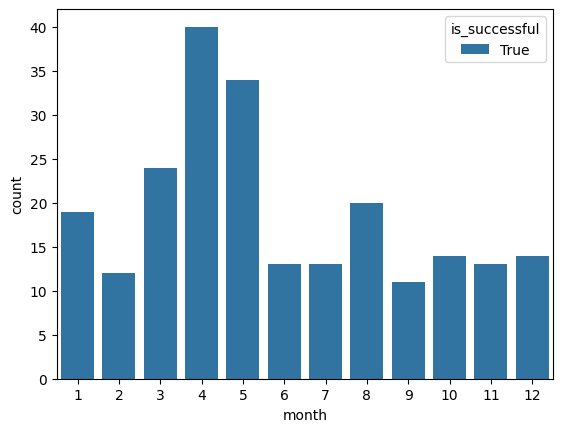

In [12]:
sns.countplot(df[df.is_successful == True], x = "month", hue ="is_successful")

# Q4

### a

In [13]:
df["is_successful"] = (df["revenue"] > df["budget"])

In [14]:
features = ["budget", "popularity", "runtime", "vote_average"]

In [15]:
X = df[features]
y = df["is_successful"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [16]:
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [17]:
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9928718939444408


Let's look at the distribution of successful vs unsuccessful movies (you can do that in various ways, I chose a pie-plot):

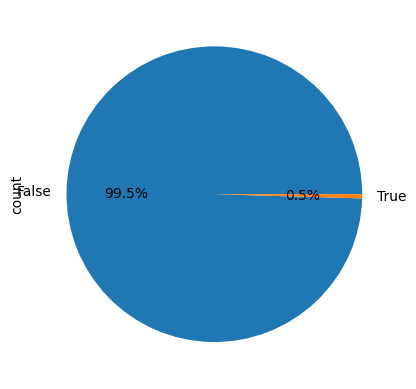

In [18]:
df['is_successful'].value_counts().plot.pie(autopct="%.1f%%")
plt.show()

A simple/naive/random/trivia model that will always predict "False" will receive an accuracy of 0.995 - better than the accuracy of our model (!!) 
If this is our only performance measure- don't use the model.  
The model needs to be evaluated using other measures. 

# Q5

In [19]:
df5 = df[df["keywords"]>""]

Or:

In [20]:
df5=df5[(df5['keywords'] != 'nan') ]

Then:

In [21]:
kw_list = df5['keywords'].str.split(',', expand=True)
melted = kw_list.melt(value_name='key')
melted = melted.dropna()
melted['key'].value_counts().sort_values(ascending = False).head(2)

key
 short film    346
concert        320
Name: count, dtype: int64

# Q6

Note: multiple answers were accepted for this question, as people understood it in different ways

In [23]:
grouped = df.groupby(['genres', 'month'])['popularity'].mean().reset_index()

avg_genres = grouped.groupby('genres')['popularity'].mean().reset_index()

top4_genres = avg_genres.sort_values(by='popularity', ascending=False).head(4)['genres']

df6 = grouped[grouped['genres'].isin(top4_genres)]


<Axes: xlabel='month', ylabel='popularity'>

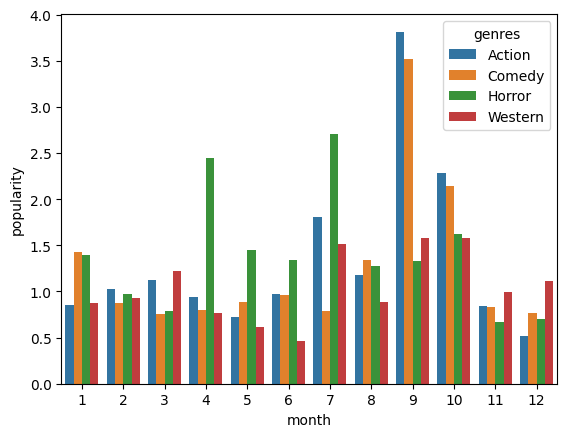

In [24]:
sns.barplot(data=df6, x = "month", y="popularity", hue="genres")